In [39]:
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings

dti_metric_list_str=['FA']
dti_metric_list=['FA']
CCx_list=['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']
dti_metric=0  #0 : FA / 1 : RD ..

ccxID=4

warnings.filterwarnings('ignore')

cwd = os.getcwd()
print("Current working directory: {0}".format(cwd))
pathfile=r'/media/nicolascatz/4d767acb-7d35-42a5-b630-86a61f8774d0/nicolascatz/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'
pathfile=r'D:/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'

pathdata=pathfile+'data/'
pathdata_tractography=pathfile+'data/Corrected_Tractometry2025/MiddleAge/'
pathcsv=pathfile+'CSV/'
os.chdir(pathfile)

Aging_INDICES = pd.read_excel('Subjects_ID_MA_03022026_5s.xlsx', sheet_name='Compte Rendus')
Aging_INDICES

Current working directory: D:\DATA\Projets\CRPN_DTI_AGING_DPAKNC


,Subject,Sex,Age_MRI,Group,date MRI study,JND day,Age_JND,Seq order,done,JND
0,CTS01,F,59,M,2022-10-20,2026-01-22,63,"3,2,1",YES,3.4071
1,CTS08,F,56,M,2023-02-07,2025-12-08,59,"1,3,2",YES,10.2730
2,CTS10,F,49,M,2023-02-15,2025-12-12,52,"3,1,2",YES,5.5957
3,CTS13,F,42,M,2023-03-30,2025-12-08,45,"2,3,1",YES,5.8071
4,CTS14,F,43,M,2023-05-17,2025-12-12,46,"1,2,3",YES,7.9630


In [40]:


addtocc='_MA_03022026_5s' #addtocc='_46removed'
titreSubjectcsv='Subject_preproc'+addtocc
SubjectTable=Aging_INDICES[['Subject','Sex', 'Age_MRI', 'Group', 'JND']]
SubjectTable


,Subject,Sex,Age_MRI,Group,JND
0,CTS01,F,59,M,3.4071
1,CTS08,F,56,M,10.2730
2,CTS10,F,49,M,5.5957
3,CTS13,F,42,M,5.8071
4,CTS14,F,43,M,7.9630


In [41]:

listsub=SubjectTable['Subject'].values
SubjectTable

,Subject,Sex,Age_MRI,Group,JND
0,CTS01,F,59,M,3.4071
1,CTS08,F,56,M,10.2730
2,CTS10,F,49,M,5.5957
3,CTS13,F,42,M,5.8071
4,CTS14,F,43,M,7.9630


In [42]:
Aging_INDICES

,Subject,Sex,Age_MRI,Group,date MRI study,JND day,Age_JND,Seq order,done,JND
0,CTS01,F,59,M,2022-10-20,2026-01-22,63,"3,2,1",YES,3.4071
1,CTS08,F,56,M,2023-02-07,2025-12-08,59,"1,3,2",YES,10.2730
2,CTS10,F,49,M,2023-02-15,2025-12-12,52,"3,1,2",YES,5.5957
3,CTS13,F,42,M,2023-03-30,2025-12-08,45,"2,3,1",YES,5.8071
4,CTS14,F,43,M,2023-05-17,2025-12-12,46,"1,2,3",YES,7.9630


In [43]:
listsuball=['CTS01','CTS08','CTS10','CTS13','CTS14']




print('len list sub  : ' ,len(listsub))

print('list subject table : ' ,len(SubjectTable))


SubjectTable

len list sub  :  5
list subject table :  5


,Subject,Sex,Age_MRI,Group,JND
0,CTS01,F,59,M,3.4071
1,CTS08,F,56,M,10.2730
2,CTS10,F,49,M,5.5957
3,CTS13,F,42,M,5.8071
4,CTS14,F,43,M,7.9630


In [44]:
#One hot encoder for groups
from sklearn.preprocessing import OneHotEncoder

category_column = SubjectTable[['Group']]

encoder = OneHotEncoder(sparse_output=False)
# Ajuster et transformer la colonne catégorielle
encoded_categories = encoder.fit_transform(category_column)
# Créer un DataFrame avec les colonnes encodées
encoded_df = pd.DataFrame(encoded_categories, columns=encoder.get_feature_names_out(['Group']))
# Concaténer le DataFrame encodé avec le DataFrame original (sans la colonne catégorielle)
SubjectTable = pd.concat([SubjectTable.drop(columns=['Sex']), encoded_df], axis=1)
# Afficher le DataFrame résultant
SubjectTable.head()

SubjectTable.to_csv(titreSubjectcsv+'.csv', index=False)  



In [45]:
# %% CREATE CSV allsub DTI FILE FOR GIVEN CC and metric 

dti_metric_list=['FA']
CCx_list=['CC_1']
CCx_list=['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']

tracto_folder_path = './Corrected_Tractometry2025/MiddleAge/'
pathdata_tractography
print(len(listsub))

for dti_metric in dti_metric_list:
    for CCx in CCx_list:
        list_CCx_val = []
        for subj in listsub:
            file_path = os.path.join(pathdata_tractography, f'sub-{subj}_{dti_metric}_tractometry_mergedTOMs.csv')
            data_sub = pd.read_csv(file_path, sep=";")
            list_CCx_val.append(data_sub[CCx].values)
       
        dfCCx = pd.DataFrame(list_CCx_val)
        dfCCx.to_csv(pathcsv+ CCx +'_'+dti_metric+addtocc+'.csv', index=False)  
dfCCx

5


,0,1,2,3,4,5,6,7,8,9,...,88,89,90,91,92,93,94,95,96,97
0,0.274470,0.287272,0.314487,0.328709,0.340177,0.339351,0.339473,0.355065,0.381067,0.411245,...,0.378497,0.360255,0.348226,0.346441,0.331232,0.299211,0.276577,0.264698,0.243041,0.256894
1,0.268978,0.266549,0.286107,0.306229,0.320927,0.325975,0.336074,0.351225,0.363989,0.387894,...,0.360548,0.351712,0.337760,0.334096,0.331244,0.317910,0.298213,0.276341,0.247048,0.250292
2,0.224517,0.202511,0.239669,0.269871,0.290208,0.323521,0.346082,0.365661,0.378786,0.391221,...,0.382444,0.352140,0.330276,0.324773,0.323153,0.322845,0.306223,0.286130,0.248782,0.263038
3,0.298765,0.291522,0.300582,0.297577,0.301186,0.334168,0.368553,0.377315,0.379958,0.382470,...,0.381049,0.367438,0.353305,0.342517,0.350778,0.348432,0.344026,0.313575,0.270691,0.270979
4,0.288678,0.291973,0.325184,0.331192,0.347770,0.368135,0.385603,0.396124,0.402440,0.412027,...,0.410849,0.405628,0.396866,0.388161,0.366870,0.353184,0.320262,0.284048,0.242805,0.249962


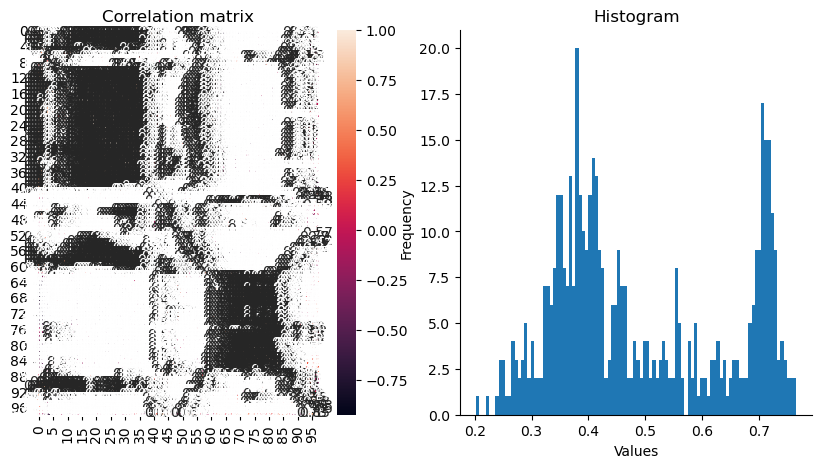

In [46]:
fig,ax=plt.subplots(1,2,figsize=(10,5))
sns.heatmap(dfCCx.corr(),annot=True,ax=ax[0])
ax[0].set_title('Correlation matrix')

ax[1].hist(dfCCx.values.flatten(),bins=100)
ax[1].set_title('Histogram')
ax[1].set_xlabel('Values')
ax[1].set_ylabel('Frequency')
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)




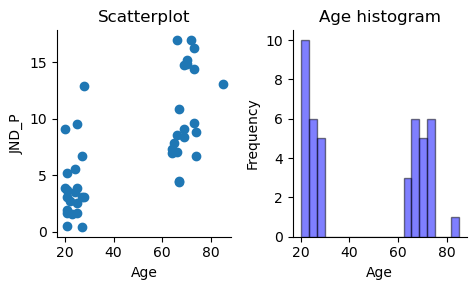

In [7]:

fig,ax=plt.subplots(1,2,figsize=(5,3))

ax[0].scatter(SubjectTable['age'],SubjectTable['JND_P'])
ax[0].set_title('Scatterplot')
ax[0].set_xlabel('Age')
ax[0].set_ylabel('JND_P')
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

ax[1].hist(SubjectTable['age'],bins=20,color='blue',alpha=0.5,label='Age',edgecolor='black')
ax[1].set_title('Age histogram')
ax[1].set_xlabel('Age')
ax[1].set_ylabel('Frequency')
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

plt.tight_layout()

